# ACGCN Multi-Omics Node Classification

In [26]:
import os
import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import roc_curve, precision_recall_curve, auc


In [32]:
results_dir = "results/gene_prediction"
os.makedirs(results_dir, exist_ok=True)

model_type = "ACGNN"     # example
net_type = "CPDB"
in_feats = 300
num_epochs = 200

prefix = f"{model_type}_{net_type}"


In [87]:
metrics_file = os.path.join(
    "results/gene_prediction",
    f"{args.model_type}_{args.net_type}_performance_metrics_epo{args.num_epochs}_2048.csv"
)


metrics_df = pd.read_csv(metrics_file)
metrics_df.head()


,Epoch,Time per Epoch (s),CPU Usage (MB),GPU Usage (MB)
0,1,0.485842,26.5,0.0
1,2,0.285795,60.3,0.0
2,3,0.319672,0.0,0.0
3,4,0.325038,88.9,0.0
4,5,0.310542,89.1,0.0


OSError: [Errno 28] No space left on device: '/Users/ericsali/Documents/2024_Winter/Project_gnn/reactome_markers/gnn_pathways/ACGNN/results/gene_prediction/epoch_time.png'

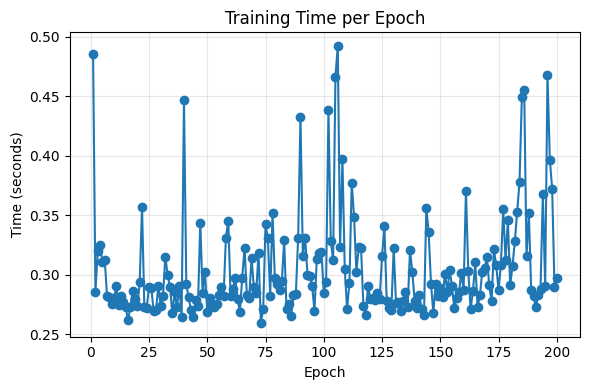

In [88]:
import matplotlib.pyplot as plt
import os

plt.figure(figsize=(6, 4))

plt.plot(metrics_df["Epoch"], metrics_df["Time per Epoch (s)"], marker="o")

plt.xlabel("Epoch")
plt.ylabel("Time (seconds)")
plt.title("Training Time per Epoch")
plt.grid(True, alpha=0.3)
plt.tight_layout()

plt.savefig(os.path.join(results_dir, "epoch_time.png"), dpi=300)
plt.show()



In [46]:
scores_file = os.path.join(
    results_dir,
    f"ACGNN_CPDB_predicted_scores_threshold0.99_epo200.csv"
)

scores_df = pd.read_csv(scores_file)
scores_df.head()


,Node Name,Score,Label
0,GAB1,0.990648,2
1,GRB2,0.960293,3
2,FNTA,0.026249,3
3,FNTB,0.009661,3
4,MRE11,0.042628,0


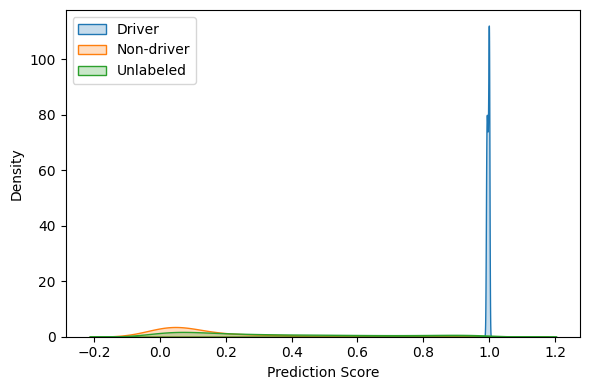

In [48]:
label_map = {
    2: "Driver",
    0: "Non-driver",
    3: "Unlabeled"
}

plt.figure(figsize=(6, 4))

for lbl, name in label_map.items():
    sns.kdeplot(
        scores_df[scores_df["Label"] == lbl]["Score"],
        label=name,
        fill=True
    )

plt.xlabel("Prediction Score")
plt.ylabel("Density")
plt.legend()
plt.tight_layout()

plt.savefig(os.path.join(results_dir, "score_distribution.png"), dpi=300)
plt.show()



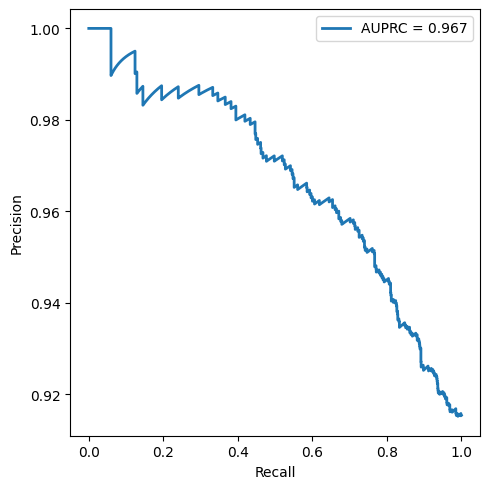

In [56]:
import matplotlib.pyplot as plt
import os

from sklearn.metrics import precision_recall_curve, auc

labeled = scores_df[scores_df["Label"].isin([0, 2, 3])]

y_true = labeled["Label"].isin([2, 3]).astype(int).values
y_score = labeled["Score"].values

precision, recall, _ = precision_recall_curve(y_true, y_score)
aupr = auc(recall, precision)


plt.figure(figsize=(5, 5))
plt.plot(recall, precision, lw=2, label=f"AUPRC = {aupr:.3f}")

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.legend()
plt.tight_layout()

plt.savefig(os.path.join(results_dir, "pr_curve.png"), dpi=300)
plt.show()




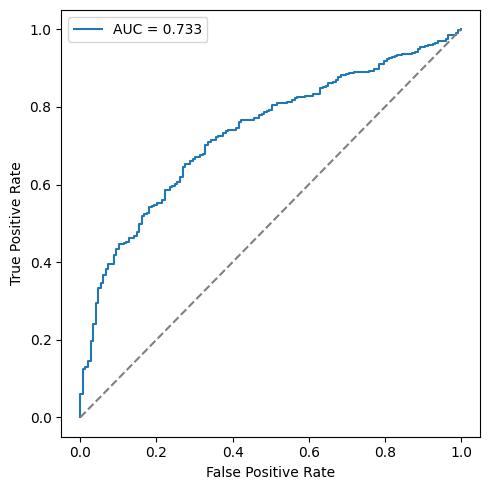

In [57]:
fpr, tpr, _ = roc_curve(y_true, y_score)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(5,5))
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.3f}")
plt.plot([0,1], [0,1], linestyle="--", color="gray")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.tight_layout()

plt.savefig(os.path.join(results_dir, "roc_curve.png"), dpi=300)
plt.show()


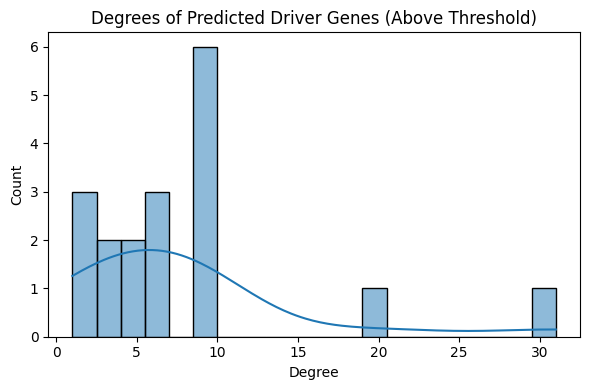

In [59]:
deg_above = pd.read_csv(
    os.path.join(results_dir, f"ACGNN_CPDB_predicted_driver_gene_degrees_above_epo14_2048.csv")
)

plt.figure(figsize=(6,4))
sns.histplot(deg_above["Degree"], bins=20, kde=True)
plt.xlabel("Degree")
plt.ylabel("Count")
plt.title("Degrees of Predicted Driver Genes (Above Threshold)")
plt.tight_layout()

plt.savefig(os.path.join(results_dir, "degree_distribution_above.png"), dpi=300)
plt.show()


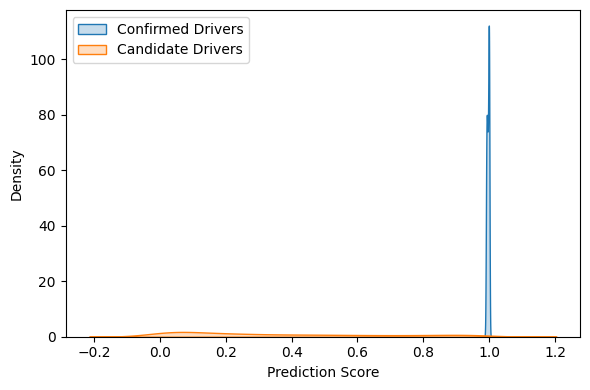

In [61]:
plt.figure(figsize=(6, 4))

sns.kdeplot(
    scores_df[scores_df["Label"] == 2]["Score"],
    label="Confirmed Drivers",
    fill=True
)

sns.kdeplot(
    scores_df[scores_df["Label"] == 3]["Score"],
    label="Candidate Drivers",
    fill=True
)

plt.xlabel("Prediction Score")
plt.ylabel("Density")
plt.legend()
plt.tight_layout()

plt.savefig(os.path.join(results_dir, "kde_confirmed_vs_candidates.png"), dpi=300)
plt.show()



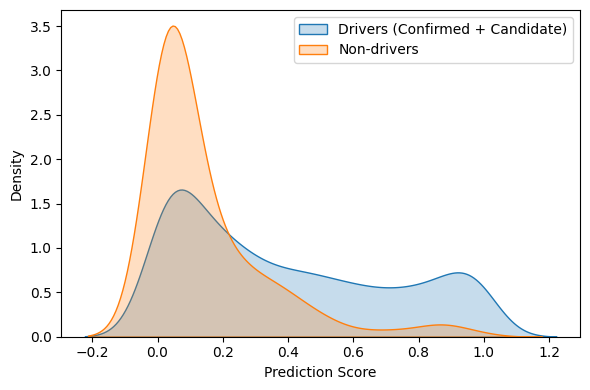

In [62]:
plt.figure(figsize=(6, 4))

sns.kdeplot(
    scores_df[scores_df["Label"].isin([2, 3])]["Score"],
    label="Drivers (Confirmed + Candidate)",
    fill=True
)

sns.kdeplot(
    scores_df[scores_df["Label"] == 0]["Score"],
    label="Non-drivers",
    fill=True
)

plt.xlabel("Prediction Score")
plt.ylabel("Density")
plt.legend()
plt.tight_layout()

plt.savefig(os.path.join(results_dir, "kde_drivers_vs_nondrivers.png"), dpi=300)
plt.show()


In [ ]:
print("✅ All analysis plots displayed and saved successfully.")


In [69]:
import os
import csv
import time
import psutil
import pandas as pd
import torch
from tqdm import tqdm

def save_epoch_metrics(epoch_times, cpu_usages, gpu_usages, args, output_dir):
    os.makedirs(output_dir, exist_ok=True)

    csv_path = os.path.join(
        output_dir,
        f"{args.model_type}_{args.net_type}_epoch_metrics_epo{args.num_epochs}.csv"
    )

    df = pd.DataFrame({
        "epoch": range(1, len(epoch_times) + 1),
        "epoch_time_sec": epoch_times,
        "cpu_usage_percent": cpu_usages,
        "gpu_memory_MB": gpu_usages
    })

    df.to_csv(csv_path, index=False)
    print(f"✅ Epoch metrics saved to {csv_path}")


In [84]:
def save_overall_metrics(
    total_time,
    avg_time,
    avg_cpu,
    avg_gpu,
    args,
    results_dir
):
    csv_path = os.path.join(
        results_dir,
        f"{args.model_type}_{args.net_type}_overall_metrics_epo{args.num_epochs}.csv"
    )

    df = pd.DataFrame([{
        "total_training_time_sec": total_time,
        "avg_time_per_epoch_sec": avg_time,
        "avg_cpu_usage_percent": avg_cpu,
        "avg_gpu_memory_MB": avg_gpu,
        "num_epochs": args.num_epochs,
        "learning_rate": args.learning_rate,
        "hidden_feats": args.hidden_feats
    }])

    df.to_csv(csv_path, index=False)
    print(f"✅ Overall metrics saved to {csv_path}")


In [71]:
def save_all_node_scores(scores, labels, nodes, args, results_dir):

    node_names = list(nodes.keys())

    df = pd.DataFrame({
        "Gene": node_names,
        "Score": scores,
        "Label": labels.cpu().numpy()
    })

    csv_path = os.path.join(
        results_dir,
        f"{args.model_type}_{args.net_type}_all_node_scores_epo{args.num_epochs}.csv"
    )

    df.to_csv(csv_path, index=False)
    print(f"✅ All node scores saved to {csv_path}")


In [72]:
def save_ranked_predictions(ranking, args, results_dir):


    csv_path = os.path.join(
        results_dir,
        f"{args.model_type}_{args.net_type}_ranked_non_labeled_epo{args.num_epochs}.csv"
    )

    df = pd.DataFrame(ranking, columns=["Gene", "Score"])
    df.to_csv(csv_path, index=False)

    print(f"✅ Ranked non-labeled predictions saved to {csv_path}")


In [73]:
save_epoch_metrics(epoch_times, cpu_usages, gpu_usages, args, results_dir)


✅ Epoch metrics saved to results/gene_prediction/ACGNN_CPDB_epoch_metrics_epo200.csv


In [85]:
# ================= After training loop =================

total_time = sum(epoch_times)
avg_time = total_time / args.num_epochs
avg_cpu = sum(cpu_usages) / args.num_epochs
avg_gpu = sum(gpu_usages) / args.num_epochs

save_overall_metrics(
    total_time=total_time,
    avg_time=avg_time,
    avg_cpu=avg_cpu,
    avg_gpu=avg_gpu,
    args=args,
    results_dir=results_dir
)



✅ Overall metrics saved to results/gene_prediction/ACGNN_CPDB_overall_metrics_epo200.csv


In [83]:
save_all_node_scores(scores, labels, nodes, args, results_dir)
save_ranked_predictions(ranking, args, results_dir)


✅ All node scores saved to results/gene_prediction/ACGNN_CPDB_all_node_scores_epo200.csv
✅ Ranked non-labeled predictions saved to results/gene_prediction/ACGNN_CPDB_ranked_non_labeled_epo200.csv


## Configuration

In [36]:
import argparse
import torch
from src.train import train, plot_and_analyze

def get_args():
    parser = argparse.ArgumentParser(description="GNN-based Driver Gene Prediction")
    parser.add_argument('--in_feats', type=int, default=2048)
    parser.add_argument('--hidden_feats', type=int, default=1024)
    parser.add_argument('--out_feats', type=int, default=1)
    parser.add_argument('--learning_rate', type=float, default=1e-3)
    parser.add_argument('--num_epochs', type=int, default=100)
    parser.add_argument('--model_type', type=str,
                        choices=['GraphSAGE','GAT','GCN','GIN','Chebnet','HGDC','EMOGI','MTGCN','ACGNN'],
                        required=True)
    parser.add_argument('--net_type', type=str,
                        choices=['CPDB','STRING','HIPPIE'],
                        required=False)
    parser.add_argument('--device', type=str,
                        default='cuda' if torch.cuda.is_available() else 'cpu')
    parser.add_argument('--score_threshold', type=float, default=0.99)
    return parser.parse_args()

args = get_args = argparse.Namespace(
    in_feats=2048,
    hidden_feats=1024,
    out_feats=1,
    learning_rate=1e-3,
    num_epochs=200,
    model_type="ACGNN",
    net_type="CPDB",
    device="cuda" if torch.cuda.is_available() else "cpu",
    score_threshold=0.99
)

args



Namespace(in_feats=2048, hidden_feats=1024, out_feats=1, learning_rate=0.001, num_epochs=200, model_type='ACGNN', net_type='CPDB', device='cpu', score_threshold=0.99)

## Graph Construction from Multi-Omics Embeddings

In [11]:

import os
import dgl
import torch
from src.data_loader import load_data
import json
from src.utils import (choose_model, plot_roc_curve, plot_pr_curve, load_graph_data, 
                       load_oncokb_genes, plot_and_analyze, save_and_plot_results)

nodes, edges, embeddings, labels = load_graph_data(data_path)

graph = dgl.graph(edges)
graph.ndata['feat'] = embeddings
graph.ndata['label'] = labels
graph.ndata['train_mask'] = labels != -1
graph.ndata['test_mask'] = torch.ones_like(labels, dtype=torch.bool)

graph = dgl.add_self_loop(graph)

print(graph)




Graph(num_nodes=3034, num_edges=24564,
      ndata_schemes={'feat': Scheme(shape=(2048,), dtype=torch.float32), 'label': Scheme(shape=(), dtype=torch.int64), 'train_mask': Scheme(shape=(), dtype=torch.bool), 'test_mask': Scheme(shape=(), dtype=torch.bool)}
      edata_schemes={})


## 2. Network Construction (PPI → NetworkX)

In [15]:

import dgl
import torch
import torch.nn as nn
import numpy as np
import os
import time
import psutil
from tqdm import tqdm
import matplotlib.pyplot as plt
import seaborn as sns
import csv
import scipy.stats
import pandas as pd
from sklearn.metrics import roc_curve, auc, precision_recall_curve
from matplotlib.lines import Line2D
from scipy.stats import ttest_ind
from torch_geometric.nn import GCNConv
from src.models import ACGNN, HGDC, EMOGI, MTGCN, GCN, GAT, GraphSAGE, GIN, ChebNet, FocalLoss
from src.utils import (choose_model, plot_roc_curve, plot_pr_curve, load_graph_data, 
                       load_oncokb_genes, plot_and_analyze, save_and_plot_results)

device = torch.device(args.device)

model = choose_model(
    args.model_type,
    embeddings.shape[1],
    args.hidden_feats,
    args.out_feats
).to(device)

loss_fn = FocalLoss(alpha=0.25, gamma=2)
optimizer = torch.optim.Adam(model.parameters(), lr=args.learning_rate)

graph = graph.to(device)
features = graph.ndata['feat'].to(device)
labels = graph.ndata['label'].float().to(device)
train_mask = graph.ndata['train_mask'].to(device)
test_mask = graph.ndata['test_mask'].to(device)


## 3. Training

In [16]:

import time, psutil
from tqdm import tqdm

epoch_times, cpu_usages, gpu_usages = [], [], []

for epoch in tqdm(range(args.num_epochs), desc="Training"):
    start = time.time()

    cpu_usages.append(psutil.cpu_percent())
    gpu_usages.append(
        torch.cuda.memory_allocated(device) / 1024**2 if torch.cuda.is_available() else 0.0
    )

    model.train()
    logits = model(graph, features).squeeze()
    loss = loss_fn(logits[train_mask], labels[train_mask])

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    epoch_times.append(time.time() - start)

    tqdm.write(f"Epoch {epoch+1} | Loss {loss.item():.4f}")


Training:   1%|          | 1/100 [00:00<01:34,  1.05it/s]

Epoch 1 | Loss 0.0323


Training:   2%|▏         | 2/100 [00:01<01:22,  1.19it/s]

Epoch 2 | Loss 0.0329


Training:   3%|▎         | 3/100 [00:02<01:15,  1.28it/s]

...

Epoch 98 | Loss 0.0001


Training:  99%|█████████▉| 99/100 [01:13<00:00,  1.36it/s]

Epoch 99 | Loss 0.0001


Training: 100%|██████████| 100/100 [01:14<00:00,  1.35it/s]

Epoch 100 | Loss 0.0001


## 4. Inference

In [17]:
model.eval()
with torch.no_grad():
    logits = model(graph, features).squeeze()
    scores = torch.sigmoid(logits).cpu().numpy()

scores[:10]


array([1.0000000e+00, 5.5222854e-06, 1.0000000e+00, 1.7938146e-01,
       1.0000000e+00, 9.3295780e-04, 1.0000000e+00, 8.0259351e-06,
       1.0000000e+00, 2.5138059e-01], dtype=float32)

## 5. Performance

In [18]:

total_time = sum(epoch_times)
avg_epoch_time = total_time / args.num_epochs
avg_cpu = sum(cpu_usages) / args.num_epochs
avg_gpu = sum(gpu_usages) / args.num_epochs

total_time, avg_epoch_time, avg_cpu, avg_gpu


(73.92790818214417, 0.7392790818214416, 84.83200000000002, 0.0)

## 6. Candidate Driver Gene

In [19]:

node_names = list(nodes.keys())
non_labeled = [i for i,l in enumerate(labels.cpu()) if l == -1]

ranking = sorted(
    [(node_names[i], scores[i]) for i in non_labeled],
    key=lambda x: x[1],
    reverse=True
)

ranking[:20]


[('DCC', 1.0),
 ('VAV1', 1.0),
 ('PTPN11', 1.0),
 ('KCNMB1', 1.0),
 ('MAP2K2', 1.0),
 ('EGFR', 1.0),
 ('CDKN1A', 1.0),
 ('GPHN', 1.0),
 ('LCK', 1.0),
 ('ATM', 1.0),
 ('NBN', 1.0),
 ('MMP7', 1.0),
 ('BLM', 1.0),
 ('EXT2', 1.0),
 ('PYCARD', 1.0),
 ('SMARCE1', 1.0),
 ('IL2', 1.0),
 ('TSHR', 1.0),
 ('ERCC1', 1.0),
 ('SRSF3', 1.0)]

## 7. Run Training Pipeline

In [ ]:

interaction_df = pd.read_csv("data/__protein_interaction_p_value_CPDB_ppi_0.99.csv")
save_networkx_graphs([interaction_df], [None], raw_dir)

dataset = GeneGraphDataset(data_dir)
model = train_model(dataset)
torch.save(model.state_dict(), model_ckpt)


## 8. Threshold-Based Driver Gene Selection

In [20]:

pred_above = [(g,s) for g,s in ranking if s >= args.score_threshold]
pred_below = [(g,s) for g,s in ranking if s < args.score_threshold]

len(pred_above), len(pred_below)


(187, 2508)

In [ ]:
## 9. Network Degree Analysis

In [21]:
from collections import defaultdict

degree_above, degree_below = defaultdict(int), defaultdict(int)
ground_truth = {node_names[i] for i,l in enumerate(labels.cpu()) if l == 1}

for src, dst in edges:
    if node_names[dst] in ground_truth:
        if node_names[src] in dict(pred_above):
            degree_above[node_names[src]] += 1
        elif node_names[src] in dict(pred_below):
            degree_below[node_names[src]] += 1


In [ ]:
## 10. Distributional and Structural Analysis

In [63]:
print(f"Model: {args.model_type}")
print(f"Graph: {args.net_type}")
print(f"Epochs: {args.num_epochs}")
print(f"Avg Epoch Time: {avg_epoch_time:.2f}s")
print(f"Predicted Drivers ≥ τ: {len(pred_above)}")


Model: ACGNN
Graph: CPDB
Epochs: 200
Avg Epoch Time: 0.74s
Predicted Drivers ≥ τ: 187
